# **CSE427 Sec 03 Group 04 Spring'26**
**Project Title:** Understanding Anime Success: Predicting Popularity and Genre Influence Using Machine Learning

**Project Folder (Limited Access):** https://drive.google.com/drive/folders/1VMlxmMks89mqoFL4zw-LBtFcbfjEi1QP

**Dataset Link (Open):** https://drive.google.com/file/d/1qA4KMLrM-W71PRpPq-i0kGS6aI2oG9is/view?usp=sharing

</br>

**Group Members:**

Mohammad Hasibul Amin

Fabiha Tarannum Areena

Zawad Ahsan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# **Exploratory Data Analysis (EDA)**

**anime_id:** Unique identifier assigned to each anime entry.

**title:** Name of the anime series or movie.

**type:** Category of anime such as TV series, Movie, OVA, ONA, or Special.

**episodes:** Total number of episodes released for the anime.

**status:** Current status of the anime (e.g., Finished Airing, Currently Airing, Not yet aired).

**source:** Original source material (Manga, Light Novel, Original, Game, Visual Novel, etc.).

**genre:** Categories describing the theme or style — an anime may belong to multiple genres.

**studio:** Animation studio responsible for producing the anime.

**duration:** Average length of each episode.

**rating:** Age rating classification (e.g., PG-13, R, G).

**score:** Average user rating on a scale from 1 to 10 — our **target variable**.

**scored_by:** Number of users who contributed to the rating score.

**rank:** Ranking position based on user scores.

**popularity:** Ranking based on the number of users who added it to their lists.

**members:** Total MyAnimeList users who added the anime to their watch list.

**favorites:** Number of users who marked the anime as a favorite.

In [ ]:
# Read dataset from a public Google Drive File
file_link = 'https://drive.google.com/file/d/1qA4KMLrM-W71PRpPq-i0kGS6aI2oG9is/view?usp=sharing'
file_id = file_link.split('/')[-2]
new_link = f'https://drive.google.com/uc?id={file_id}'
df = pd.read_csv(new_link)
df.head()

,anime_id,title,title_english,title_japanese,title_synonyms,image_url,type,source,episodes,status,...,background,premiered,broadcast,related,producer,licensor,studio,genre,opening_theme,ending_theme
0,11013,Inu x Boku SS,Inu X Boku Secret Service,妖狐×僕SS,Youko x Boku SS,https://myanimelist.cdn-dena.com/images/anime/...,TV,Manga,12,Finished Airing,...,Inu x Boku SS was licensed by Sentai Filmworks...,Winter 2012,Fridays at Unknown,"{'Adaptation': [{'mal_id': 17207, 'type': 'man...","Aniplex, Square Enix, Mainichi Broadcasting Sy...",Sentai Filmworks,David Production,"Comedy, Supernatural, Romance, Shounen","['""Nirvana"" by MUCC']","['#1: ""Nirvana"" by MUCC (eps 1, 11-12)', '#2: ..."
1,2104,Seto no Hanayome,My Bride is a Mermaid,瀬戸の花嫁,The Inland Sea Bride,https://myanimelist.cdn-dena.com/images/anime/...,TV,Manga,26,Finished Airing,...,NaN,Spring 2007,Unknown,"{'Adaptation': [{'mal_id': 759, 'type': 'manga...","TV Tokyo, AIC, Square Enix, Sotsu",Funimation,Gonzo,"Comedy, Parody, Romance, School, Shounen","['""Romantic summer"" by SUN&LUNAR']","['#1: ""Ashita e no Hikari (明日への光)"" by Asuka Hi..."
2,5262,Shugo Chara!! Doki,Shugo Chara!! Doki,しゅごキャラ！！どきっ,"Shugo Chara Ninenme, Shugo Chara! Second Year",https://myanimelist.cdn-dena.com/images/anime/...,TV,Manga,51,Finished Airing,...,NaN,Fall 2008,Unknown,"{'Adaptation': [{'mal_id': 101, 'type': 'manga...","TV Tokyo, Sotsu",NaN,Satelight,"Comedy, Magic, School, Shoujo","['#1: ""Minna no Tamago (みんなのたまご)"" by Shugo Cha...","['#1: ""Rottara Rottara (ロッタラ ロッタラ)"" by Buono! ..."
3,721,Princess Tutu,Princess Tutu,プリンセスチュチュ,NaN,https://myanimelist.cdn-dena.com/images/anime/...,TV,Original,38,Finished Airing,...,Princess Tutu aired in two parts. The first pa...,Summer 2002,Fridays at Unknown,"{'Adaptation': [{'mal_id': 1581, 'type': 'mang...","Memory-Tech, GANSIS, Marvelous AQL",ADV Films,Hal Film Maker,"Comedy, Drama, Magic, Romance, Fantasy","['""Morning Grace"" by Ritsuko Okazaki']","['""Watashi No Ai Wa Chiisaikeredo"" by Ritsuko ..."
4,12365,Bakuman. 3rd Season,Bakuman.,バクマン。,Bakuman Season 3,https://myanimelist.cdn-dena.com/images/anime/...,TV,Manga,25,Finished Airing,...,NaN,Fall 2012,Unknown,"{'Adaptation': [{'mal_id': 9711, 'type': 'mang...","NHK, Shueisha",NaN,J.C.Staff,"Comedy, Drama, Romance, Shounen","['#1: ""Moshimo no Hanashi (もしもの話)"" by nano.RIP...","['#1: ""Pride on Everyday"" by Sphere (eps 1-13)..."


# **Check Dataset Shape**

In [ ]:
df.shape

(14478, 31)

# **Understand Data Types**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14478 entries, 0 to 14477
Data columns (total 31 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   anime_id        14478 non-null  int64  
 1   title           14478 non-null  object 
 2   title_english   5724 non-null   object 
 3   title_japanese  14443 non-null  object 
 4   title_synonyms  8937 non-null   object 
 5   image_url       14382 non-null  object 
 6   type            14478 non-null  object 
 7   source          14478 non-null  object 
 8   episodes        14478 non-null  int64  
 9   status          14478 non-null  object 
 10  airing          14478 non-null  bool   
 11  aired_string    14478 non-null  object 
 12  aired           14478 non-null  object 
 13  duration        14478 non-null  object 
 14  rating          13934 non-null  object 
 15  score           14478 non-null  float64
 16  scored_by       14478 non-null  int64  
 17  rank            12904 non-null 

# **Basic Statistical Summary**

In [ ]:
df.describe(include='all')

,anime_id,title,title_english,title_japanese,title_synonyms,image_url,type,source,episodes,status,...,background,premiered,broadcast,related,producer,licensor,studio,genre,opening_theme,ending_theme
count,14478.000000,14478,5724,14443,8937,14382,14478,14478,14478.000000,14478,...,1057,4096,4271,14478,8288,3373,8544,14414,14478,14478
unique,NaN,14477,5606,13701,8575,14382,7,16,NaN,3,...,1038,221,441,9420,3221,193,778,4544,4328,5458
top,NaN,Hinamatsuri,Cyborg 009,ゲゲゲの鬼太郎,Minna no Uta,https://myanimelist.cdn-dena.com/images/anime/...,TV,Unknown,NaN,Finished Airing,...,Includes claymation short which was shown befo...,Spring 2017,Unknown,[],NHK,Funimation,Toei Animation,Hentai,[],[]
freq,NaN,2,4,6,189,1,4271,4210,NaN,13791,...,5,80,2241,4515,427,726,725,868,9784,8807
mean,17377.229866,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.308399,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,13165.315011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,43.443451,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,4389.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,15135.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,31146.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# **Check Unique Values**

In [ ]:
df.nunique()

,0
anime_id,14478
title,14477
title_english,5606
title_japanese,13701
title_synonyms,8575
image_url,14382
type,7
source,16
episodes,196
status,3


# **Check Missing Values**

In [ ]:
df.isnull().sum()

,0
anime_id,0
title,0
title_english,8754
title_japanese,35
title_synonyms,5541
image_url,96
type,0
source,0
episodes,0
status,0


# **Check Percentage of Missing Values**

In [ ]:
missing_percent = df.isnull().sum() / len(df) * 100
missing_percent.sort_values(ascending=False)

,0
background,92.699268
licensor,76.702583
premiered,71.708800
broadcast,70.500069
title_english,60.464153
producer,42.754524
studio,40.986324
title_synonyms,38.271861
rank,10.871667
rating,3.757425


# **Differentiate Categorical and Numerical Values**

In [ ]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
num_cols = df.select_dtypes(include=np.number).columns.tolist()
print('Categorical Variables:')
print(cat_cols)
print('\nNumerical Variables:')
print(num_cols)

Categorical Variables:
['title', 'title_english', 'title_japanese', 'title_synonyms', 'image_url', 'type', 'source', 'status', 'aired_string', 'aired', 'duration', 'rating', 'background', 'premiered', 'broadcast', 'related', 'producer', 'licensor', 'studio', 'genre', 'opening_theme', 'ending_theme']

Numerical Variables:
['anime_id', 'episodes', 'score', 'scored_by', 'rank', 'popularity', 'members', 'favorites']


# **Removing Unnecessary Columns**

In [ ]:
df = df.drop(columns=['image_url', 'opening_theme', 'ending_theme'], errors='ignore')

# **Check Duplicate Data**

In [ ]:
df.duplicated().sum()

np.int64(0)

# **Analyze Anime Types**

In [ ]:
df['type'].value_counts()

,count
type,
TV,4271
OVA,3612
Movie,2624
Special,1948
ONA,1144
Music,849
Unknown,30


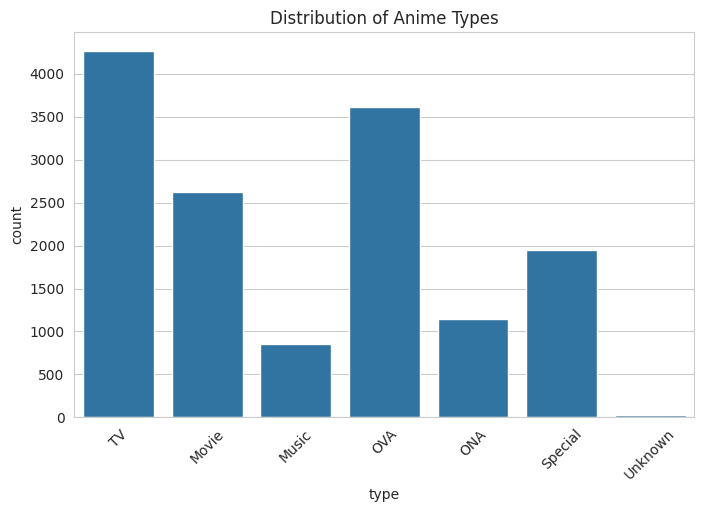

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='type')
plt.title('Distribution of Anime Types')
plt.xticks(rotation=45)
plt.show()

# **Analyze Score Distribution**

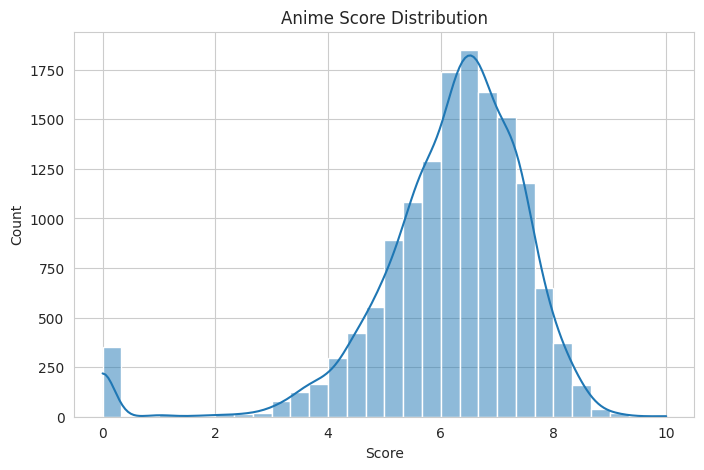

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['score'], bins=30, kde=True)
plt.title('Anime Score Distribution')
plt.xlabel('Score')
plt.show()

**Insight:** Most anime scores between 6-8

# **Popularity Analysis**

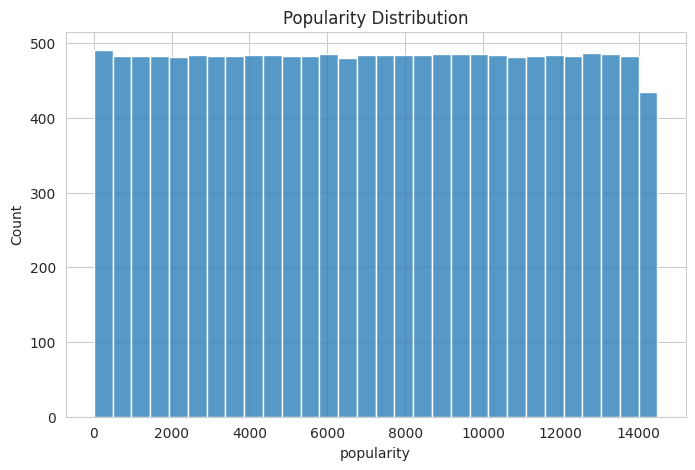

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['popularity'], bins=30)
plt.title('Popularity Distribution')
plt.show()

**Checking Most Popular Animes**

In [ ]:
df.sort_values('members', ascending=False).head(10)[['title', 'members']]

,title,members
7913,Death Note,1456378
8123,Shingeki no Kyojin,1345842
6296,Sword Art Online,1301616
2555,Fullmetal Alchemist: Brotherhood,1199091
8863,One Punch Man,1020754
1235,Tokyo Ghoul,1013138
13606,Angel Beats!,1010771
2999,Steins;Gate,1010330
13726,Code Geass: Hangyaku no Lelouch,986897
4504,Naruto,980265


# **Episode Distribution**

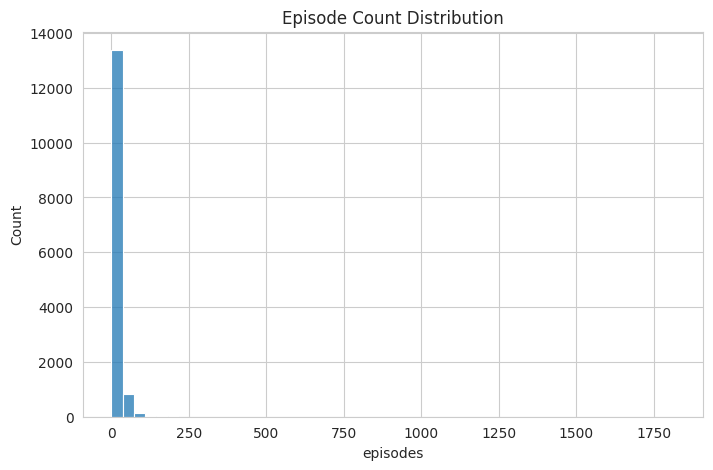

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['episodes'], bins=50)
plt.title('Episode Count Distribution')
plt.show()

# **Studio Analysis**

In [ ]:
df['studio'].value_counts().head(10)

,count
studio,
Toei Animation,725
Sunrise,447
J.C.Staff,314
Madhouse,311
Production I.G,251
TMS Entertainment,248
Studio Deen,241
Studio Pierrot,240
Nippon Animation,202


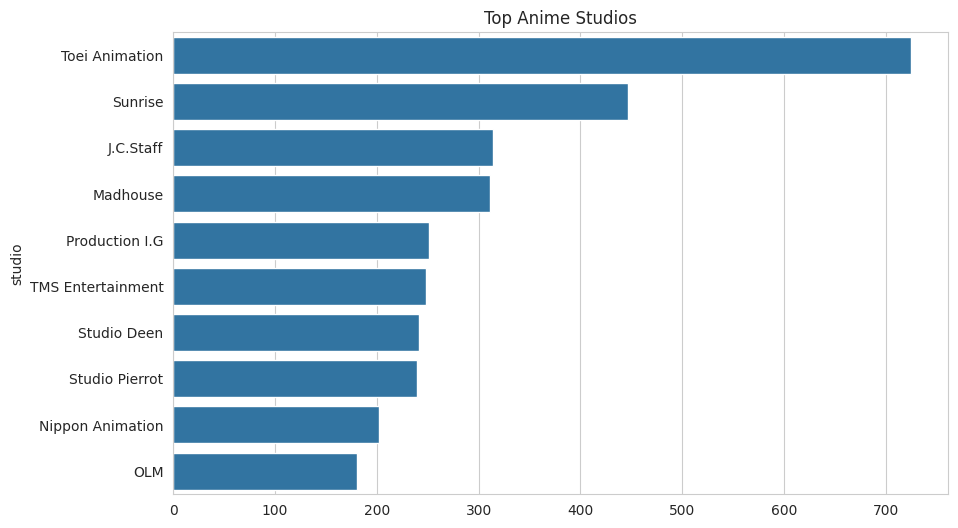

In [ ]:
top_studios = df['studio'].value_counts().head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_studios.values, y=top_studios.index)
plt.title('Top Anime Studios')
plt.show()

# **Studio Performance Analysis**

In [ ]:
studio_scores = df.groupby('studio')['score'].mean().sort_values(ascending=False)
studio_scores.head(10)

,score
studio,
"Artland, Magic Bus",9.110
"J.C.Staff, Egg Firm",8.615
"Madhouse, Satelight, Graphinica",8.530
"Xebec, AIC",8.460
"Studio Ghibli, Studio Hibari",8.380
"Gainax, Tatsunoko Production",8.320
"Studio Gallop, Studio Comet",8.280
"A-1 Pictures, Trigger, CloverWorks",8.170
"Shirogumi, Shin-Ei Animation",8.130


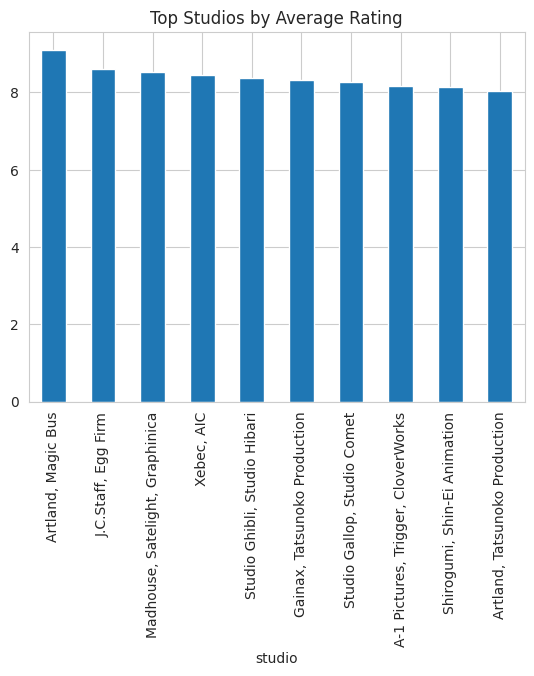

In [ ]:
studio_scores.head(10).plot(kind='bar')
plt.title('Top Studios by Average Rating')
plt.show()

# **Genre Analysis**

In [ ]:
from collections import Counter

df['genre'] = df['genre'].astype(str)

genres = df['genre'].dropna().str.split(',')
genre_list = []
for g in genres:
    genre_list.extend([x.strip() for x in g])

genre_counts = Counter(genre_list)
print(genre_counts.most_common(10))

[('Comedy', 5251), ('Action', 3253), ('Fantasy', 2703), ('Adventure', 2582), ('Drama', 2294), ('Sci-Fi', 2272), ('Kids', 2003), ('Shounen', 1771), ('Romance', 1634), ('Slice of Life', 1532)]


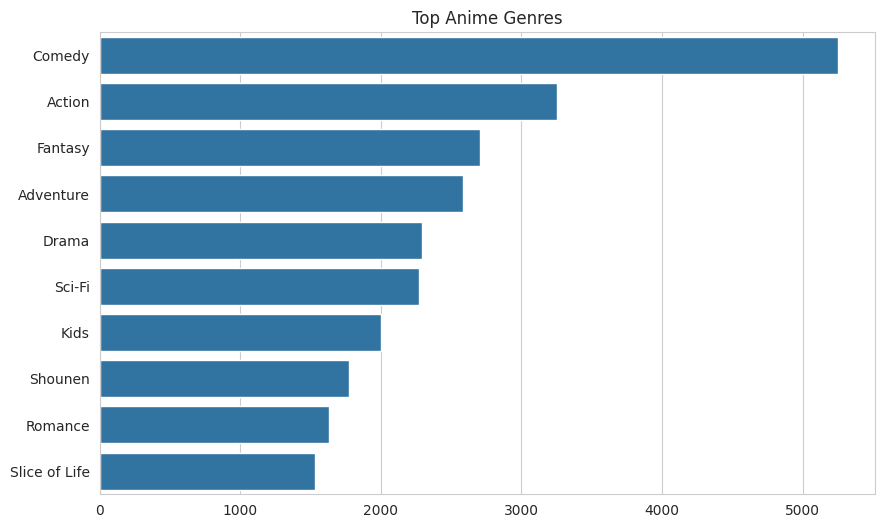

In [ ]:
top_genres_dict = dict(genre_counts.most_common(10))
plt.figure(figsize=(10, 6))
sns.barplot(x=list(top_genres_dict.values()), y=list(top_genres_dict.keys()))
plt.title('Top Anime Genres')
plt.show()

# **Score vs Popularity Relationship**

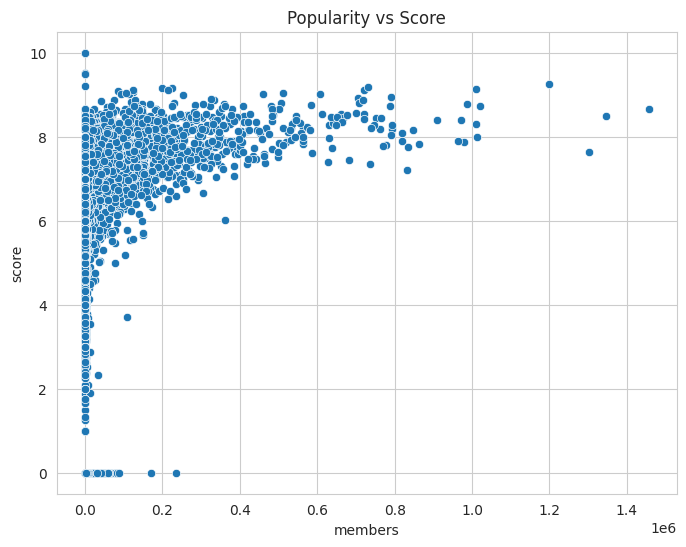

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='members', y='score')
plt.title('Popularity vs Score')
plt.show()

High popularity does not always mean higher score

# **Top Rated Anime**

In [ ]:
df.sort_values('score', ascending=False)[['title', 'score']].head(10)

,title,score
14407,Ittekimasu,10.00
14467,Kyouiku Eiga-sai Jushou Anime Series,10.00
14317,Kuunyan no Koutsuu Anzen: Tadashii Jitensha no...,10.00
548,Manichi ga Tsurai Kimochi Wakarimasu ka: Yurus...,10.00
14403,Dokidoki Little Ooyasan,9.52
14454,Tat-chan - Momo-chan no Fushigina Taiken,9.50
14208,Hashire John,9.50
2555,Fullmetal Alchemist: Brotherhood,9.25
3129,Okaachan Gomen ne,9.20
1028,Kimi no Na wa.,9.19


# **Most Favorited Anime**

In [ ]:
df.sort_values('favorites', ascending=False)[['title', 'favorites']].head(10)

,title,favorites
2555,Fullmetal Alchemist: Brotherhood,106895
2999,Steins;Gate,92423
7913,Death Note,88696
34,One Piece,69760
418,Hunter x Hunter (2011),64375
8123,Shingeki no Kyojin,64032
13726,Code Geass: Hangyaku no Lelouch,63614
6296,Sword Art Online,50042
10918,Tengen Toppa Gurren Lagann,50040
2783,Clannad: After Story,47380


# **Correlation Matrix**

<Figure size 800x600 with 0 Axes>

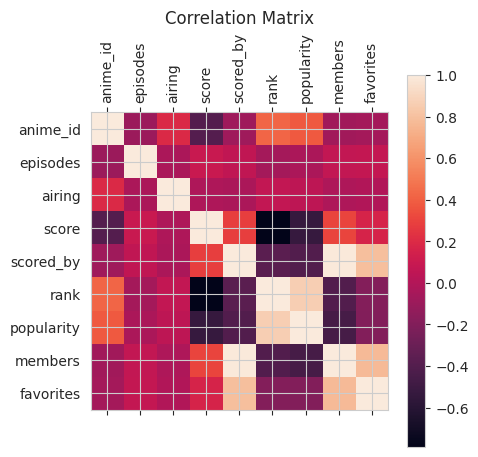

In [ ]:
plt.figure(figsize=(8, 6))
correlation_matrix = df.corr(numeric_only=True)
plt.matshow(correlation_matrix)
plt.title('Correlation Matrix')
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.colorbar()
plt.show()

# **Feature Engineering**

In [ ]:
# Bin episodes into interpretable groups
df['episode_category'] = pd.cut(
    df['episodes'],
    bins=[0, 12, 24, 50, 200, 10000],
    labels=['short', 'standard', 'medium', 'long', 'very_long']
)
df['episode_category'].value_counts()

,count
episode_category,
short,10895
medium,1286
standard,1117
long,627
very_long,49


In [ ]:
# 'duration' is a string like '24 min. per ep.' — extract the number into a numeric column
df['duration_min'] = df['duration'].str.extract(r'(\d+)').astype(float)
print('Sample duration_min values:')
print(df['duration_min'].describe())

Sample duration_min values:
count    14073.000000
mean        17.770127
std         13.472988
min          1.000000
25%          4.000000
50%         22.000000
75%         25.000000
max         59.000000
Name: duration_min, dtype: float64


# **Data Pre-Processing**

### Step 1 — Drop Irrelevant Columns
**WHY:** Drop text-heavy, ID, and date columns *before* imputing missing values.

The actual dataset contains extra columns not listed in the data dictionary:
`title_english`, `title_japanese`, `title_synonyms`, `related`, `producer`, `licensor`, `airing`, `aired_string`.
These are all dropped here. `duration` is also dropped because `duration_min` (numeric) now replaces it.
`episodes` is dropped because `episode_category` captures it as a categorical bin.

In [ ]:
df.drop(
    columns=[
        'anime_id', 'title', 'title_english', 'title_japanese', 'title_synonyms',
        'background', 'synopsis', 'studio', 'aired', 'aired_string',
        'broadcast', 'premiered', 'related', 'producer', 'licensor',
        'airing', 'duration', 'episodes'
    ],
    inplace=True,
    errors='ignore'
)

df.columns = df.columns.str.strip()
print('Remaining columns:', df.columns.tolist())

Remaining columns: ['type', 'source', 'status', 'rating', 'score', 'scored_by', 'rank', 'popularity', 'members', 'favorites', 'genre', 'episode_category', 'duration_min']


### Step 2 — Handle Missing Values
Numerical → fill with median (robust to outliers)

Categorical → fill with mode

In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print('Missing values remaining:', df.isnull().sum().sum())

Missing values remaining: 0


### Step 3 — Genre Encoding (Multi-label Binary Columns)
Each of the top 10 genres becomes its own binary (0/1) column.

In [ ]:
from collections import Counter

genres = df['genre'].astype(str).str.split(',')
genre_list = [g.strip() for sub in genres for g in sub]
top_genres = [g for g, _ in Counter(genre_list).most_common(10)]

for genre in top_genres:
    df[genre] = df['genre'].apply(lambda x: 1 if genre in str(x) else 0)

df.drop(columns=['genre'], inplace=True)
print('Top 10 genres encoded:', top_genres)

Top 10 genres encoded: ['Comedy', 'Action', 'Fantasy', 'Adventure', 'Drama', 'Sci-Fi', 'Kids', 'Shounen', 'Romance', 'Slice of Life']


### Step 4 — One-Hot Encoding
Includes `episode_category` engineered above.

An `assert` at the end confirms no string columns remain — this prevents the
ValueError that would otherwise appear in Step 7 during scaling.

In [ ]:
df = pd.get_dummies(
    df,
    columns=['type', 'source', 'rating', 'status', 'episode_category'],
    drop_first=True
)

df = df.fillna(0)

# confirm no string columns remain before scaling
remaining_str = df.select_dtypes(include=['object']).columns.tolist()
assert len(remaining_str) == 0, f'String columns still present: {remaining_str}'

print(f'All clear. Final shape: {df.shape}')

All clear. Final shape: (14478, 49)


### Step 5 — Define Target and Features

In [ ]:
X = df.drop(columns=['score'])
y = df['score']

print('Feature matrix shape:', X.shape)
print('Target shape:', y.shape)

Feature matrix shape: (14478, 48)
Target shape: (14478,)


### Step 6 — Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')

Train size: 11582 | Test size: 2896


### Step 7 — Feature Scaling
**WHY:** Applied only to X (features), never to y (target).
Scaler is fit on training data only to prevent data leakage.
Scaled versions are used only for Linear Regression.
Tree-based models (Decision Tree, Random Forest, XGBoost) use unscaled X.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Scaling complete. X_train_scaled shape:', X_train_scaled.shape)

Scaling complete. X_train_scaled shape: (11582, 48)


# **Model Training & Evaluation**

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

def evaluate_model(name, y_true, y_pred, y_train_true, y_train_pred):
    """Print RMSE, MSE and R² for both train and test sets to detect overfitting."""
    test_mse  = mean_squared_error(y_true, y_pred)
    test_rmse = np.sqrt(test_mse)
    test_r2   = r2_score(y_true, y_pred)

    train_mse  = mean_squared_error(y_train_true, y_train_pred)
    train_rmse = np.sqrt(train_mse)
    train_r2   = r2_score(y_train_true, y_train_pred)

    print(f"\n{'='*40}")
    print(f' {name}')
    print(f"{'='*40}")
    print(f'  Train → RMSE: {train_rmse:.4f} | MSE: {train_mse:.4f} | R²: {train_r2:.4f}')
    print(f'  Test  → RMSE: {test_rmse:.4f} | MSE: {test_mse:.4f} | R²: {test_r2:.4f}')

    return {
        'Model': name,
        'Train RMSE': round(train_rmse, 4), 'Test RMSE': round(test_rmse, 4),
        'Train R²':   round(train_r2, 4),   'Test R²':   round(test_r2, 4)
    }

## **Model 1 — Linear Regression**
- Baseline model
- Easy to interpret
- Shows linear relationships
- Uses **scaled** features

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr       = lr.predict(X_test_scaled)
y_pred_lr_train = lr.predict(X_train_scaled)

results_lr = evaluate_model('Linear Regression', y_test, y_pred_lr, y_train, y_pred_lr_train)


 Linear Regression
  Train → RMSE: 0.6409 | MSE: 0.4107 | R²: 0.8073
  Test  → RMSE: 0.6420 | MSE: 0.4122 | R²: 0.8118


## **Model 2 — Decision Tree**
- Captures non-linear relationships
- Works well with mixed data
- No scaling dependency
- `max_depth=10` prevents overfitting

In [ ]:
from sklearn.tree import DecisionTreeRegressor

# max_depth = 10 — an unbounded tree memorizes training data (overfits badly)
dt = DecisionTreeRegressor(random_state=42, max_depth=10)
dt.fit(X_train, y_train)

y_pred_dt       = dt.predict(X_test)
y_pred_dt_train = dt.predict(X_train)

results_dt = evaluate_model('Decision Tree', y_test, y_pred_dt, y_train, y_pred_dt_train)


 Decision Tree
  Train → RMSE: 0.4531 | MSE: 0.2053 | R²: 0.9037
  Test  → RMSE: 0.4805 | MSE: 0.2309 | R²: 0.8946


## **Model 3 — Random Forest**
- Ensemble of decision trees
- Reduces overfitting compared to single tree
- Strong baseline for tabular data

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf       = rf.predict(X_test)
y_pred_rf_train = rf.predict(X_train)

results_rf = evaluate_model('Random Forest', y_test, y_pred_rf, y_train, y_pred_rf_train)


 Random Forest
  Train → RMSE: 0.1740 | MSE: 0.0303 | R²: 0.9858
  Test  → RMSE: 0.4404 | MSE: 0.1939 | R²: 0.9115


## **Model 4 — XGBoost**
- Gradient boosting: builds trees sequentially, each correcting previous errors
- Often best performer on structured/tabular data
- Included per project plan in literature review

In [ ]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=6,
                   random_state=42, verbosity=0)
xgb.fit(X_train, y_train)

y_pred_xgb       = xgb.predict(X_test)
y_pred_xgb_train = xgb.predict(X_train)

results_xgb = evaluate_model('XGBoost', y_test, y_pred_xgb, y_train, y_pred_xgb_train)


 XGBoost
  Train → RMSE: 0.2505 | MSE: 0.0627 | R²: 0.9706
  Test  → RMSE: 0.5132 | MSE: 0.2634 | R²: 0.8797


# **Baseline Model Comparison**

In [ ]:
results_df = pd.DataFrame([results_lr, results_dt, results_rf, results_xgb])
results_df = results_df.set_index('Model')
print(results_df.to_string())

                   Train RMSE  Test RMSE  Train R²  Test R²
Model                                                      
Linear Regression      0.6409     0.6420    0.8073   0.8118
Decision Tree          0.4531     0.4805    0.9037   0.8946
Random Forest          0.1740     0.4404    0.9858   0.9115
XGBoost                0.2505     0.5132    0.9706   0.8797


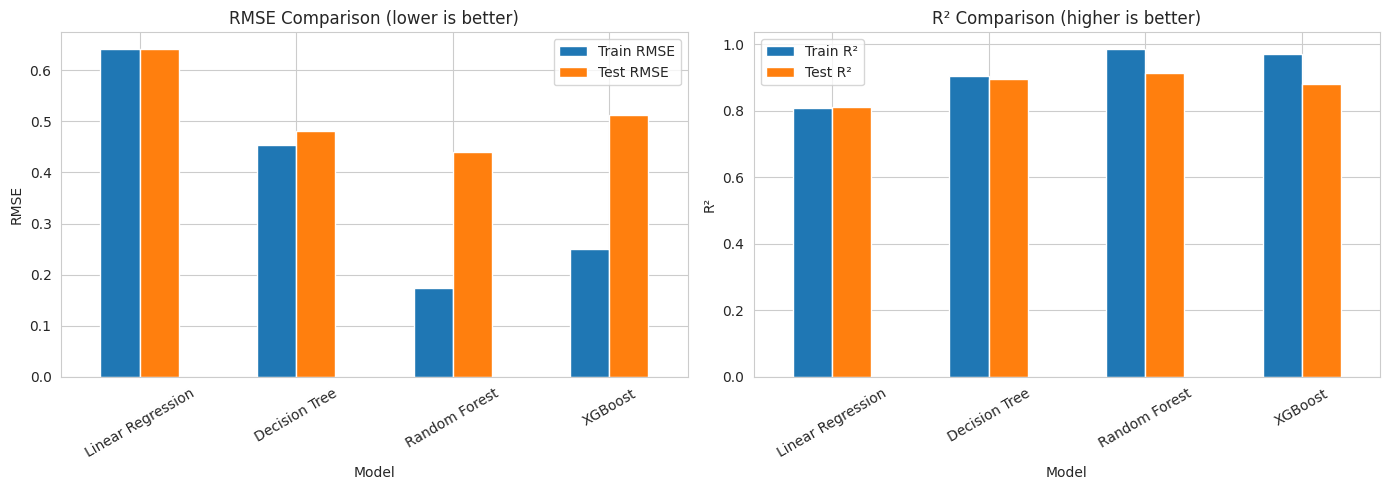

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results_df[['Train RMSE', 'Test RMSE']].plot(kind='bar', ax=axes[0], rot=30)
axes[0].set_title('RMSE Comparison (lower is better)')
axes[0].set_ylabel('RMSE')

results_df[['Train R²', 'Test R²']].plot(kind='bar', ax=axes[1], rot=30)
axes[1].set_title('R² Comparison (higher is better)')
axes[1].set_ylabel('R²')

plt.tight_layout()
plt.show()

# **Feature Importance Analysis**
Which features contribute most to predicting anime score?

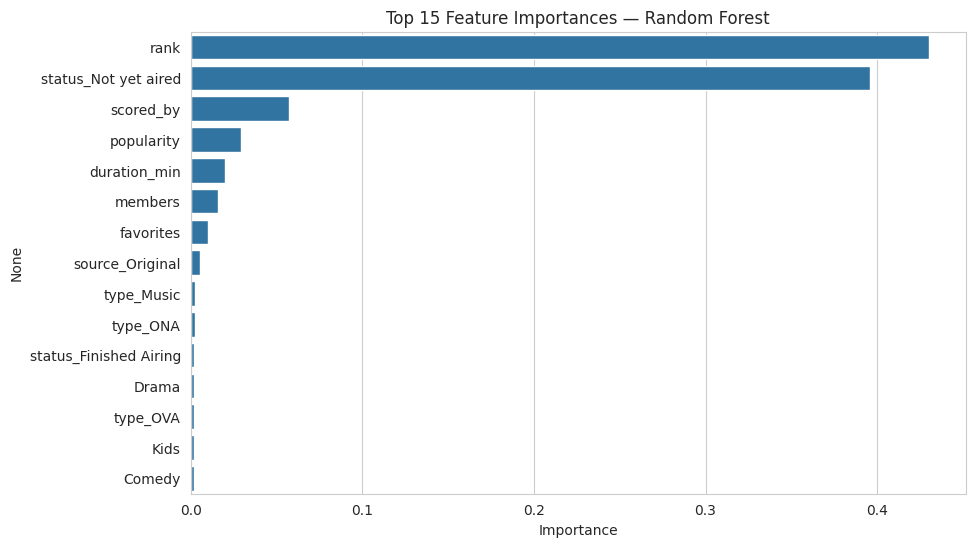

In [ ]:
feature_names = X.columns
rf_importances = pd.Series(rf.feature_importances_, index=feature_names)
rf_top = rf_importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=rf_top.values, y=rf_top.index)
plt.title('Top 15 Feature Importances — Random Forest')
plt.xlabel('Importance')
plt.show()

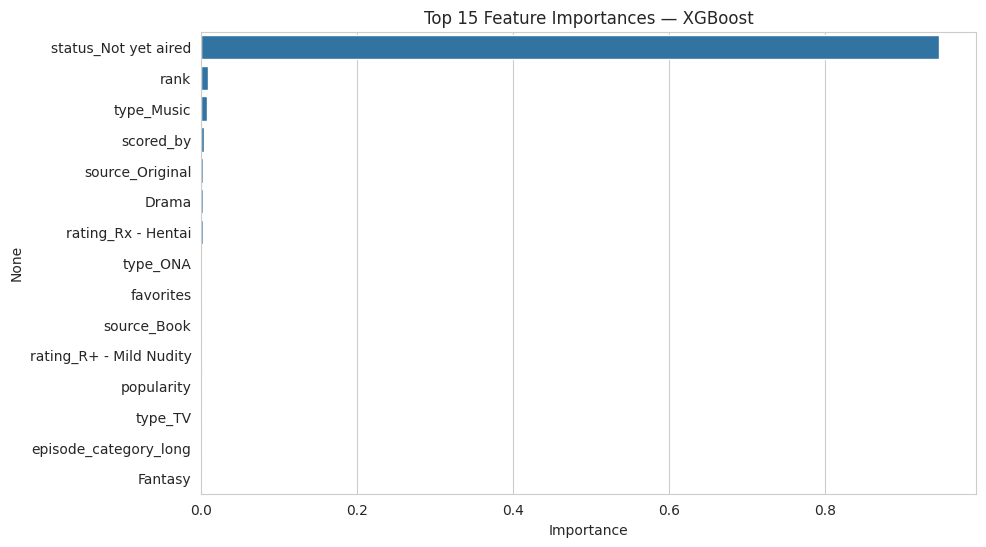

In [ ]:
xgb_importances = pd.Series(xgb.feature_importances_, index=feature_names)
xgb_top = xgb_importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=xgb_top.values, y=xgb_top.index)
plt.title('Top 15 Feature Importances — XGBoost')
plt.xlabel('Importance')
plt.show()

In [ ]:
# Store baseline results for grand final comparison at end of notebook
_baseline_results = [results_lr, results_dt, results_rf, results_xgb]

---

# **Neural Networks**

This section extends the project by applying deep learning to the same preprocessed dataset.
Three architectures are implemented and compared:

1. **Shallow Neural Network** — 3 hidden layers, baseline NN
2. **Deep Neural Network** — 5 hidden layers with L2 regularisation and learning rate scheduling
3. **Wide & Deep Neural Network** — two parallel paths (linear + deep) merged before output

## **GPU Check**

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks
import time

print("TensorFlow version:", tf.__version__)
print("GPUs available:", tf.config.list_physical_devices('GPU'))
tf.random.set_seed(42)

TensorFlow version: 2.19.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## **Neural Network Helper Functions**

In [ ]:
def evaluate_nn(name, model, X_tr, y_tr, X_te, y_te):
    """Evaluate a Keras model on train and test sets. Returns result dict."""
    p_train = model.predict(X_tr, verbose=0).flatten()
    p_test  = model.predict(X_te, verbose=0).flatten()

    train_rmse = np.sqrt(mean_squared_error(y_tr, p_train))
    test_rmse  = np.sqrt(mean_squared_error(y_te, p_test))
    train_r2   = r2_score(y_tr, p_train)
    test_r2    = r2_score(y_te, p_test)

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Train  →  RMSE: {train_rmse:.4f}  |  R²: {train_r2:.4f}")
    print(f"  Test   →  RMSE: {test_rmse:.4f}  |  R²: {test_r2:.4f}")

    return {
        'Model':      name,
        'Train RMSE': round(train_rmse, 4),
        'Test RMSE':  round(test_rmse,  4),
        'Train R²':   round(train_r2,   4),
        'Test R²':    round(test_r2,    4),
        '_preds':     p_test
    }


def plot_history(history, title):
    """Plot training vs validation loss and MAE side-by-side."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(history.history['loss'],     label='Train Loss', linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Val Loss',   linewidth=2)
    axes[0].set_title(f'{title} — Loss (MSE)')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('MSE Loss')
    axes[0].legend()

    axes[1].plot(history.history['mae'],     label='Train MAE', linewidth=2)
    axes[1].plot(history.history['val_mae'], label='Val MAE',   linewidth=2)
    axes[1].set_title(f'{title} — MAE')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MAE')
    axes[1].legend()

    plt.suptitle(title, fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()
    print(f"Stopped at epoch {len(history.history['loss'])}")


# Convert to float32 arrays for Keras
X_train_nn = X_train_scaled.astype(np.float32)
X_test_nn  = X_test_scaled.astype(np.float32)
y_train_nn = y_train.values.astype(np.float32)
y_test_nn  = y_test.values.astype(np.float32)
N_FEATURES = X_train_nn.shape[1]

print(f"NN input shape: {X_train_nn.shape}  |  N_FEATURES = {N_FEATURES}")

NN input shape: (11582, 48)  |  N_FEATURES = 48


## **Neural Network Model 1 — Shallow Neural Network**

**Architecture:** `Input(48) → Dense(128)→BN→Dropout(0.3) → Dense(64)→BN→Dropout(0.2) → Dense(32) → Output(1)`

In [ ]:
def build_shallow_nn(n):
    inp = keras.Input(shape=(n,), name='input')
    x = layers.Dense(128, activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(32, activation='relu')(x)
    out = layers.Dense(1, name='score')(x)
    model = keras.Model(inp, out, name='ShallowNN')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='mse',
        metrics=['mae']
    )
    return model

shallow_nn = build_shallow_nn(N_FEATURES)
shallow_nn.summary()

Model: "ShallowNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ score (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,409 (68.00 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 384 (1.50 KB)

Training Shallow NN...
Epoch 1/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - loss: 6.9826 - mae: 1.9983 - val_loss: 2.3148 - val_mae: 1.3455
Epoch 2/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.3725 - mae: 0.9079 - val_loss: 0.5497 - val_mae: 0.5400
Epoch 3/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.0869 - mae: 0.7998 - val_loss: 0.4824 - val_mae: 0.4905
Epoch 4/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.9894 - mae: 0.7595 - val_loss: 0.4458 - val_mae: 0.4643
Epoch 5/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.8885 - mae: 0.7233 - val_loss: 0.4118 - val_mae: 0.4447
Epoch 6/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.8417 - mae: 0.6991 - val_loss: 0.4022 - val_mae: 0.4324
Epoch 7/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7948 - mae: 0.6790 - val_loss: 0.3966 - val_mae: 0.4302
Epoch 8/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7537 - mae: 0.6578 - val_loss: 0.3956 - val_mae: 0.4462
Epoch 9/100
163/163 ━━━━

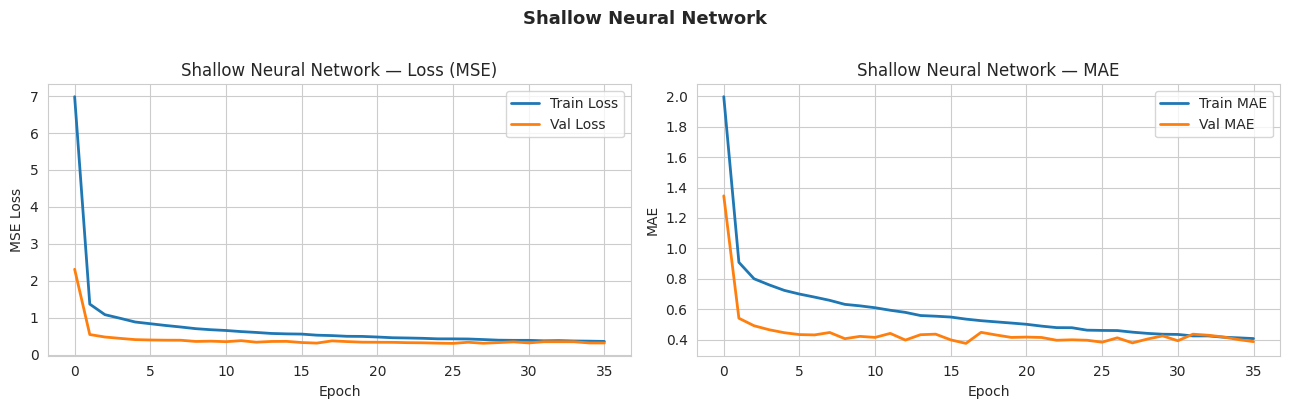

Stopped at epoch 36


In [ ]:
print("Training Shallow NN...")
t0 = time.time()

history_shallow = shallow_nn.fit(
    X_train_nn, y_train_nn,
    epochs=100,
    batch_size=64,
    validation_split=0.1,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_loss', patience=10,
                                restore_best_weights=True, verbose=1),
        callbacks.ModelCheckpoint('best_shallow.keras', monitor='val_loss',
                                  save_best_only=True, verbose=0)
    ],
    verbose=1
)
print(f"Training time: {time.time()-t0:.1f}s")
plot_history(history_shallow, 'Shallow Neural Network')

In [ ]:
results_shallow = evaluate_nn(
    'Shallow NN',
    shallow_nn, X_train_nn, y_train_nn, X_test_nn, y_test_nn
)


  Shallow NN
  Train  →  RMSE: 0.5774  |  R²: 0.8435
  Test   →  RMSE: 0.6018  |  R²: 0.8347


## **Neural Network Model 2 — Deep Neural Network**

**Architecture:** `Input(48) → 256(L2)→BN→Drop(0.4) → 128(L2)→BN→Drop(0.3) → 64→BN→Drop(0.2) → 32 → 16 → Output(1)`

In [ ]:
def build_deep_nn(n):
    inp = keras.Input(shape=(n,), name='input')
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4))(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dense(16, activation='relu')(x)
    out = layers.Dense(1, name='score')(x)
    model = keras.Model(inp, out, name='DeepNN')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=5e-4),
        loss='mse',
        metrics=['mae']
    )
    return model

deep_nn = build_deep_nn(N_FEATURES)
deep_nn.summary()

Model: "DeepNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        12,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ score (Dense)                   │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,113 (227.00 KB)

 Trainable params: 57,217 (223.50 KB)

 Non-trainable params: 896 (3.50 KB)

Training Deep NN...
Epoch 1/150
163/163 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - loss: 14.2982 - mae: 3.1731 - val_loss: 2.9823 - val_mae: 1.5142 - learning_rate: 5.0000e-04
Epoch 2/150
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.8762 - mae: 1.0579 - val_loss: 0.6384 - val_mae: 0.5770 - learning_rate: 5.0000e-04
Epoch 3/150
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.3454 - mae: 0.8802 - val_loss: 0.4839 - val_mae: 0.4847 - learning_rate: 5.0000e-04
Epoch 4/150
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.1359 - mae: 0.8114 - val_loss: 0.4321 - val_mae: 0.4513 - learning_rate: 5.0000e-04
Epoch 5/150
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.0299 - mae: 0.7668 - val_loss: 0.4166 - val_mae: 0.4453 - learning_rate: 5.0000e-04
Epoch 6/150
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.9358 - mae: 0.7236 - val_loss: 0.4107 - val_mae: 0.4373 - learning_rate: 5.0000e-04
Epoch 7/150
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8921 - mae: 0.7063 - val_loss: 0

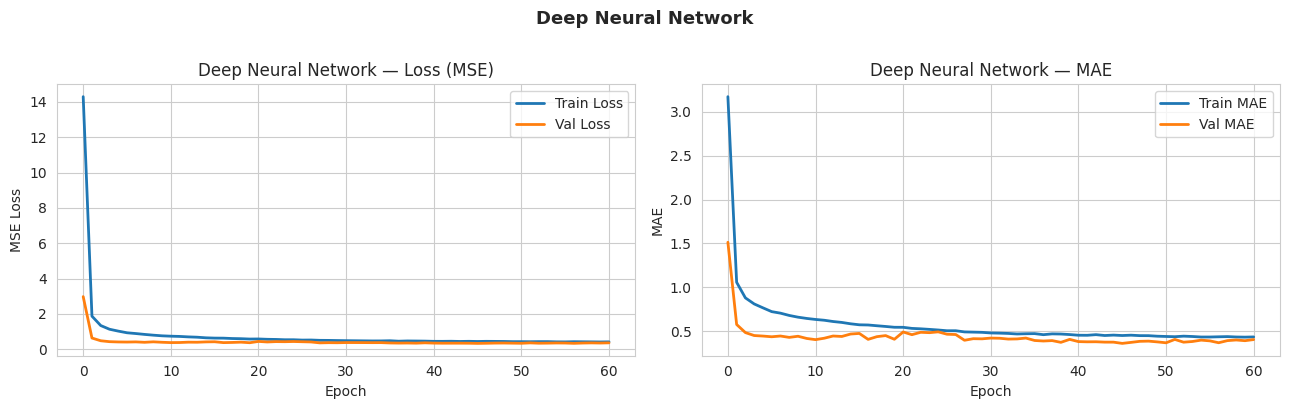

Stopped at epoch 61


In [ ]:
print("Training Deep NN...")
t0 = time.time()

history_deep = deep_nn.fit(
    X_train_nn, y_train_nn,
    epochs=150,
    batch_size=64,
    validation_split=0.1,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_loss', patience=15,
                                restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=7, min_lr=1e-6, verbose=1),
        callbacks.ModelCheckpoint('best_deep.keras', monitor='val_loss',
                                  save_best_only=True, verbose=0)
    ],
    verbose=1
)
print(f"Training time: {time.time()-t0:.1f}s")
plot_history(history_deep, 'Deep Neural Network')

In [ ]:
results_deep = evaluate_nn(
    'Deep NN',
    deep_nn, X_train_nn, y_train_nn, X_test_nn, y_test_nn
)


  Deep NN
  Train  →  RMSE: 0.5852  |  R²: 0.8393
  Test   →  RMSE: 0.6004  |  R²: 0.8354


## **Neural Network Model 3 — Wide & Deep Neural Network**

**Architecture:**
```
Wide path:  Input(48) ──────────────────────────────────────────────┐
Deep path:  Input(48) → 256→BN→Drop(0.3) → 128→BN→Drop(0.2) → 64  │
                                                                     ↓
                              Concatenate([wide, deep]) → Dense(32) → Output(1)
```

In [ ]:
def build_wide_deep_nn(n):
    inp = keras.Input(shape=(n,), name='input')

    # Wide: raw features pass straight through
    wide = inp

    # Deep: stacked dense layers learn non-linear patterns
    deep = layers.Dense(256, activation='relu')(inp)
    deep = layers.BatchNormalization()(deep)
    deep = layers.Dropout(0.3)(deep)
    deep = layers.Dense(128, activation='relu')(deep)
    deep = layers.BatchNormalization()(deep)
    deep = layers.Dropout(0.2)(deep)
    deep = layers.Dense(64, activation='relu')(deep)

    # Merge wide + deep, then final prediction
    merged = layers.Concatenate(name='wide_deep_merge')([wide, deep])
    x   = layers.Dense(32, activation='relu')(merged)
    out = layers.Dense(1, name='score')(x)

    model = keras.Model(inp, out, name='WideDeepNN')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='mse',
        metrics=['mae']
    )
    return model

wide_deep_nn = build_wide_deep_nn(N_FEATURES)
wide_deep_nn.summary()

Model: "WideDeepNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 48)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 256)       │     12,544 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_8[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 128)       │     32,896 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_9[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 64)        │      8,256 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ wide_deep_merge     │ (None, 112)       │          0 │ input[0][0],      │
│ (Concatenate)       │                   │            │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 32)        │      3,616 │ wide_deep_merge[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ score (Dense)       │ (None, 1)         │         33 │ dense_11[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 58,881 (230.00 KB)

 Trainable params: 58,113 (227.00 KB)

 Non-trainable params: 768 (3.00 KB)

Training Wide & Deep NN...
Epoch 1/120
163/163 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - loss: 4.4238 - mae: 1.4254 - val_loss: 2.5686 - val_mae: 1.4411 - learning_rate: 0.0010
Epoch 2/120
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.8060 - mae: 0.6727 - val_loss: 0.6366 - val_mae: 0.6231 - learning_rate: 0.0010
Epoch 3/120
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6611 - mae: 0.5997 - val_loss: 0.4224 - val_mae: 0.4551 - learning_rate: 0.0010
Epoch 4/120
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5925 - mae: 0.5632 - val_loss: 0.4040 - val_mae: 0.4424 - learning_rate: 0.0010
Epoch 5/120
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5347 - mae: 0.5300 - val_loss: 0.3738 - val_mae: 0.4173 - learning_rate: 0.0010
Epoch 6/120
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5027 - mae: 0.5114 - val_loss: 0.3884 - val_mae: 0.4381 - learning_rate: 0.0010
Epoch 7/120
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4785 - mae: 0.4942 - val_loss: 0.3611 - val_mae: 0.

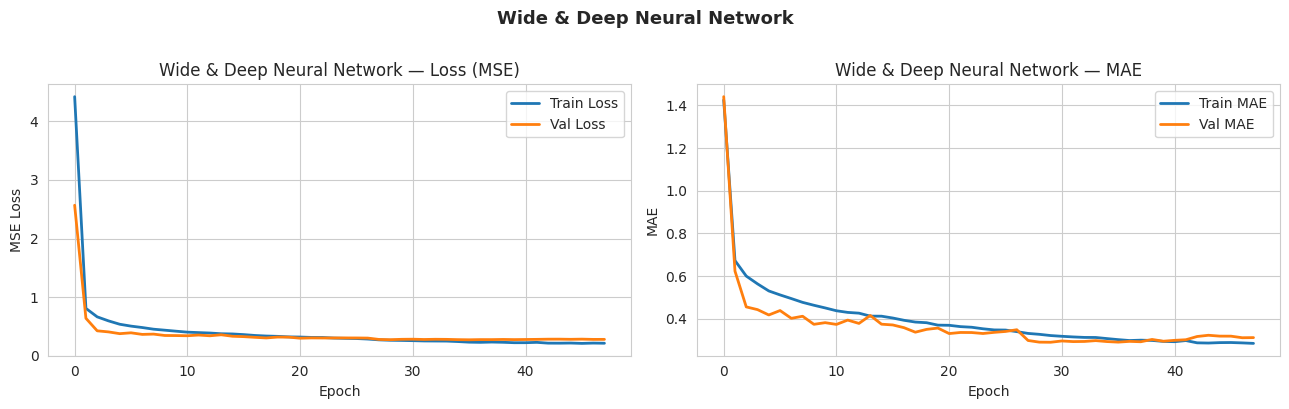

Stopped at epoch 48


In [ ]:
print("Training Wide & Deep NN...")
t0 = time.time()

history_wd = wide_deep_nn.fit(
    X_train_nn, y_train_nn,
    epochs=120,
    batch_size=64,
    validation_split=0.1,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_loss', patience=12,
                                restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=6, min_lr=1e-6, verbose=1),
        callbacks.ModelCheckpoint('best_widedeep.keras', monitor='val_loss',
                                  save_best_only=True, verbose=0)
    ],
    verbose=1
)
print(f"Training time: {time.time()-t0:.1f}s")
plot_history(history_wd, 'Wide & Deep Neural Network')

In [ ]:
results_wd = evaluate_nn(
    'Wide & Deep NN',
    wide_deep_nn, X_train_nn, y_train_nn, X_test_nn, y_test_nn
)


  Wide & Deep NN
  Train  →  RMSE: 0.4776  |  R²: 0.8930
  Test   →  RMSE: 0.5557  |  R²: 0.8590


## **Neural Network Models — Individual Comparison**

Training curves and performance metrics for the three NN architectures.

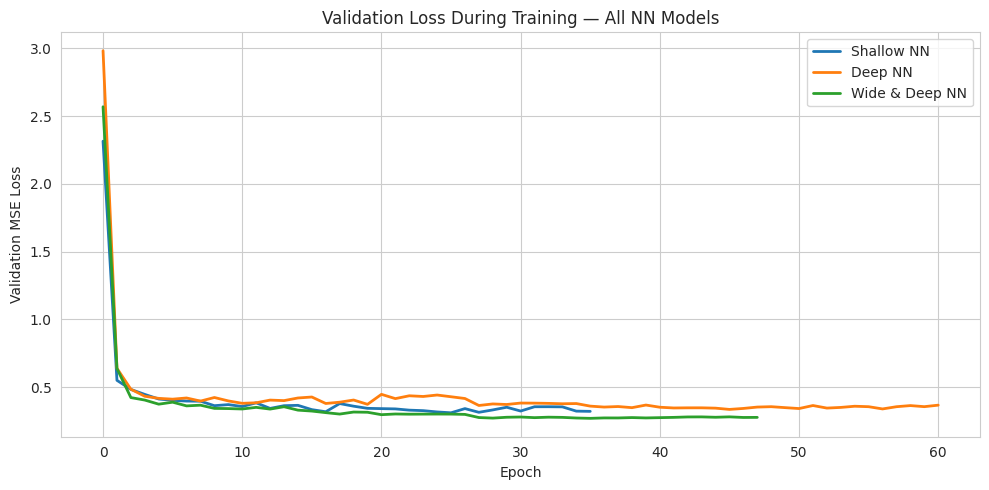

In [ ]:
# Overlaid validation loss curves — all three NNs
plt.figure(figsize=(10, 5))
plt.plot(history_shallow.history['val_loss'], label='Shallow NN',    linewidth=2)
plt.plot(history_deep.history['val_loss'],    label='Deep NN',       linewidth=2)
plt.plot(history_wd.history['val_loss'],      label='Wide & Deep NN',linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Validation MSE Loss')
plt.title('Validation Loss During Training — All NN Models')
plt.legend()
plt.tight_layout()
plt.show()

Neural Network Results:
                Train RMSE  Test RMSE  Train R²  Test R²
Model                                                   
Shallow NN          0.5774     0.6018    0.8435   0.8347
Deep NN             0.5852     0.6004    0.8393   0.8354
Wide & Deep NN      0.4776     0.5557    0.8930   0.8590


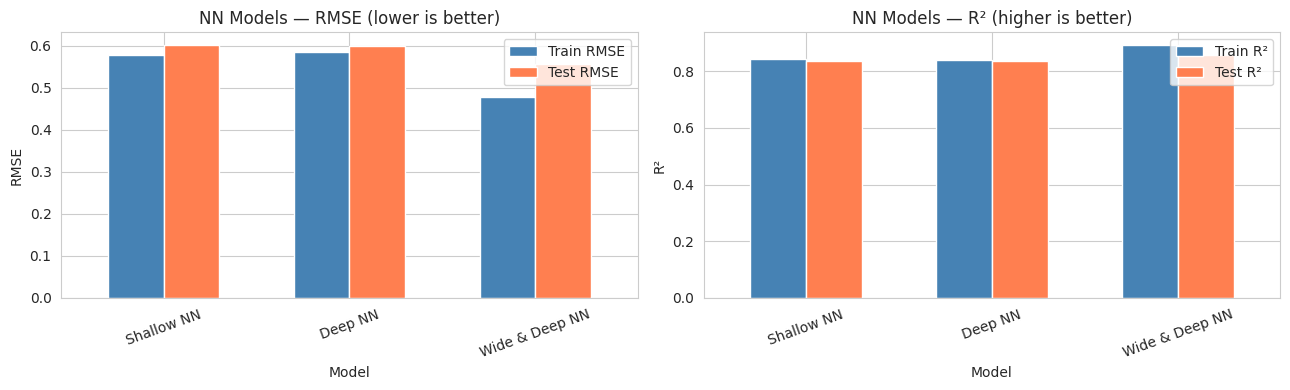

In [ ]:
# NN results table + bar chart
nn_rows = [
    {k: v for k, v in results_shallow.items() if k != '_preds'},
    {k: v for k, v in results_deep.items()    if k != '_preds'},
    {k: v for k, v in results_wd.items()      if k != '_preds'},
]
nn_results_df = pd.DataFrame(nn_rows).set_index('Model')
print("Neural Network Results:")
print(nn_results_df.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
nn_results_df[['Train RMSE', 'Test RMSE']].plot(kind='bar', ax=axes[0],
    color=['steelblue','coral'], rot=20, width=0.6)
axes[0].set_title('NN Models — RMSE (lower is better)')
axes[0].set_ylabel('RMSE')

nn_results_df[['Train R²', 'Test R²']].plot(kind='bar', ax=axes[1],
    color=['steelblue','coral'], rot=20, width=0.6)
axes[1].set_title('NN Models — R² (higher is better)')
axes[1].set_ylabel('R²')
plt.tight_layout()
plt.show()

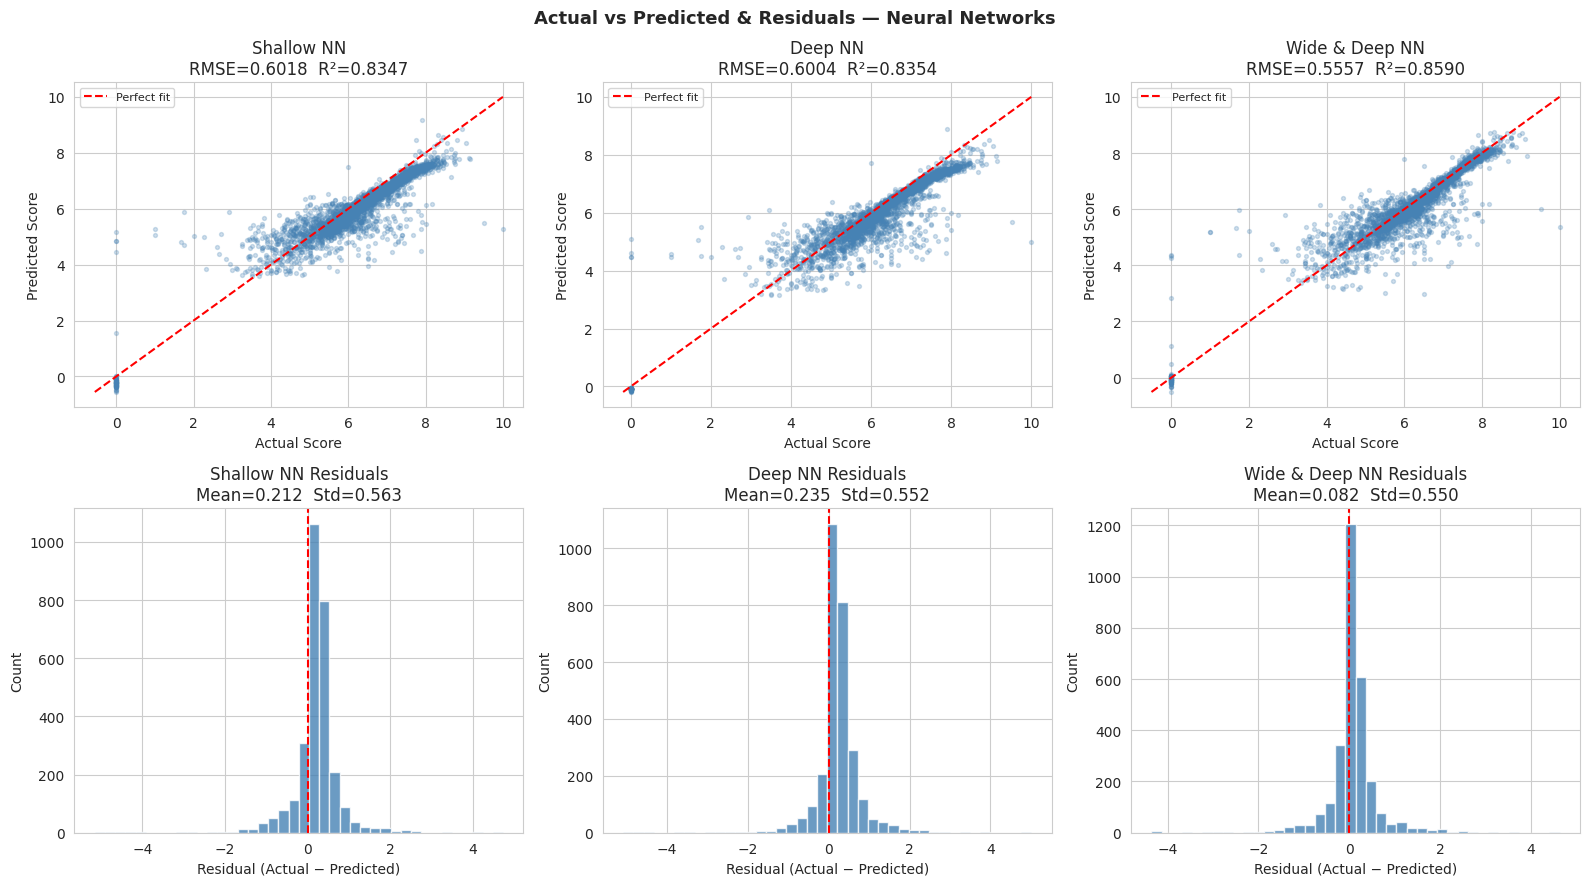

In [ ]:
# Actual vs Predicted + Residuals — all 3 NNs
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for col, (res, title) in enumerate(zip(
    [results_shallow, results_deep, results_wd],
    ['Shallow NN', 'Deep NN', 'Wide & Deep NN']
)):
    preds = res['_preds']
    residuals = y_test_nn - preds

    # Actual vs Predicted
    axes[0, col].scatter(y_test_nn, preds, alpha=0.25, s=8, color='steelblue')
    lo, hi = min(y_test_nn.min(), preds.min()), max(y_test_nn.max(), preds.max())
    axes[0, col].plot([lo, hi], [lo, hi], 'r--', linewidth=1.5, label='Perfect fit')
    axes[0, col].set_xlabel('Actual Score')
    axes[0, col].set_ylabel('Predicted Score')
    axes[0, col].set_title(f'{title}\nRMSE={res["Test RMSE"]:.4f}  R²={res["Test R²"]:.4f}')
    axes[0, col].legend(fontsize=8)

    # Residuals
    axes[1, col].hist(residuals, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    axes[1, col].axvline(0, color='red', linestyle='--', linewidth=1.5)
    axes[1, col].set_xlabel('Residual (Actual − Predicted)')
    axes[1, col].set_ylabel('Count')
    axes[1, col].set_title(f'{title} Residuals\nMean={residuals.mean():.3f}  Std={residuals.std():.3f}')

plt.suptitle('Actual vs Predicted & Residuals — Neural Networks', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---

# **Final Model Comparison — All Models**

A single unified comparison of all **7 models** trained in this notebook:
4 classical ML baselines (Linear Regression, Decision Tree, Random Forest, XGBoost)
and 3 Neural Network architectures (Shallow NN, Deep NN, Wide & Deep NN).

Models are sorted by **Test RMSE** (lower is better).

In [ ]:
# ── Grand Final Comparison: All 7 Models ─────────────────────────────────────

# Baseline rows (already computed above)
all_rows = []
for r in _baseline_results:
    all_rows.append({k: v for k, v in r.items() if k != '_preds'})

# NN rows
for r in [results_shallow, results_deep, results_wd]:
    all_rows.append({k: v for k, v in r.items() if k != '_preds'})

all_df = pd.DataFrame(all_rows).set_index('Model')
all_df['Type'] = ['Baseline']*4 + ['Neural Network']*3
all_df_sorted = all_df.sort_values('Test RMSE')

print("="*62)
print("  FINAL COMPARISON — All 7 Models (sorted by Test RMSE)")
print("="*62)
print(all_df_sorted[['Train RMSE','Test RMSE','Train R²','Test R²','Type']].to_string())
print(f"\n🏆  Best model: {all_df_sorted.index[0]}  |  Test RMSE = {all_df_sorted['Test RMSE'].iloc[0]:.4f}  |  Test R² = {all_df_sorted['Test R²'].iloc[0]:.4f}")

  FINAL COMPARISON — All 7 Models (sorted by Test RMSE)
                   Train RMSE  Test RMSE  Train R²  Test R²            Type
Model                                                                      
Random Forest          0.1740     0.4404    0.9858   0.9115        Baseline
Decision Tree          0.4531     0.4805    0.9037   0.8946        Baseline
XGBoost                0.2505     0.5132    0.9706   0.8797        Baseline
Wide & Deep NN         0.4776     0.5557    0.8930   0.8590  Neural Network
Deep NN                0.5852     0.6004    0.8393   0.8354  Neural Network
Shallow NN             0.5774     0.6018    0.8435   0.8347  Neural Network
Linear Regression      0.6409     0.6420    0.8073   0.8118        Baseline

🏆  Best model: Random Forest  |  Test RMSE = 0.4404  |  Test R² = 0.9115


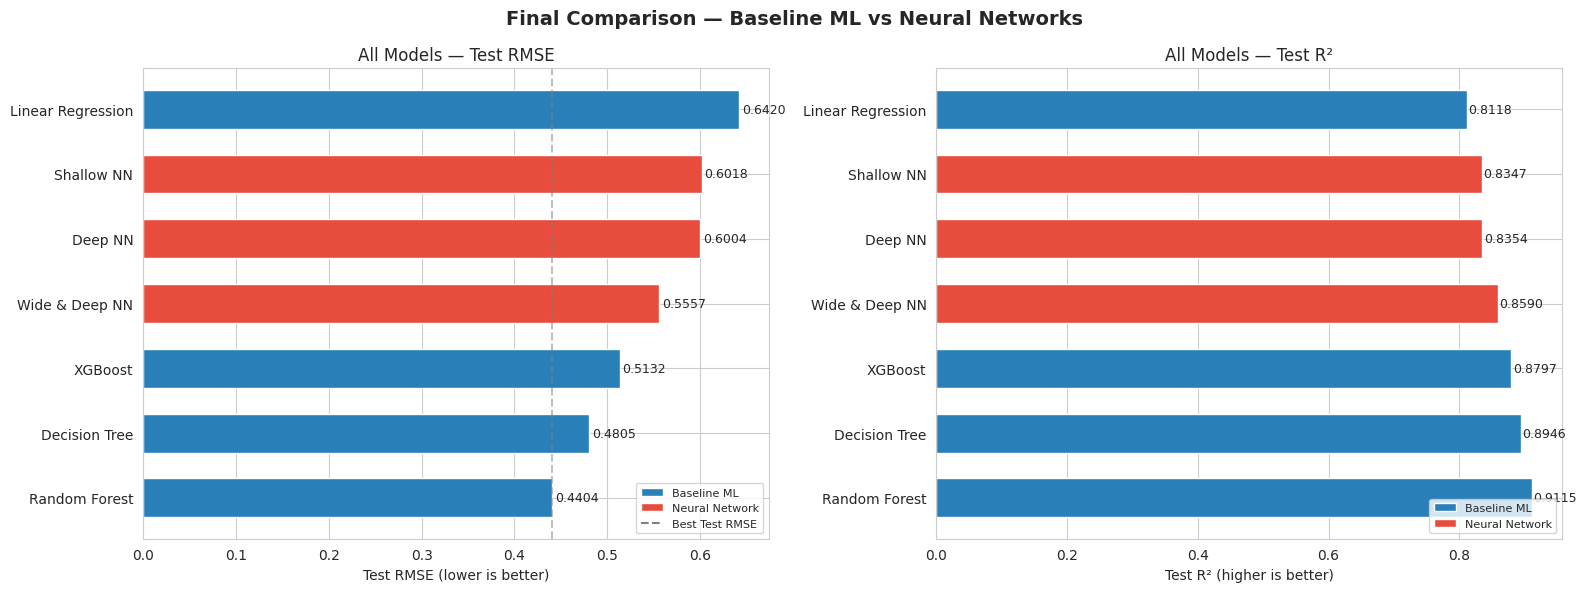

In [ ]:
# ── Final comparison charts ───────────────────────────────────────────────────
model_names = all_df_sorted.index.tolist()
test_rmse   = all_df_sorted['Test RMSE'].tolist()
test_r2     = all_df_sorted['Test R²'].tolist()
train_rmse  = all_df_sorted['Train RMSE'].tolist()
train_r2    = all_df_sorted['Train R²'].tolist()
types       = all_df_sorted['Type'].tolist()
colors      = ['#2980B9' if t == 'Baseline' else '#E74C3C' for t in types]

from matplotlib.patches import Patch
legend_els = [Patch(facecolor='#2980B9', label='Baseline ML'),
              Patch(facecolor='#E74C3C', label='Neural Network')]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Test RMSE
bars0 = axes[0].barh(model_names, test_rmse, color=colors, edgecolor='white', height=0.6)
axes[0].set_xlabel('Test RMSE (lower is better)')
axes[0].set_title('All Models — Test RMSE')
axes[0].axvline(min(test_rmse), color='gray', linestyle='--', alpha=0.5, label='Best')
for bar, val in zip(bars0, test_rmse):
    axes[0].text(val + 0.003, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9)
axes[0].legend(handles=legend_els + [plt.Line2D([0],[0],color='gray',linestyle='--',label='Best Test RMSE')],
               loc='lower right', fontsize=8)

# Test R²
bars1 = axes[1].barh(model_names, test_r2, color=colors, edgecolor='white', height=0.6)
axes[1].set_xlabel('Test R² (higher is better)')
axes[1].set_title('All Models — Test R²')
for bar, val in zip(bars1, test_r2):
    axes[1].text(val + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9)
axes[1].legend(handles=legend_els, loc='lower right', fontsize=8)

plt.suptitle('Final Comparison — Baseline ML vs Neural Networks', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

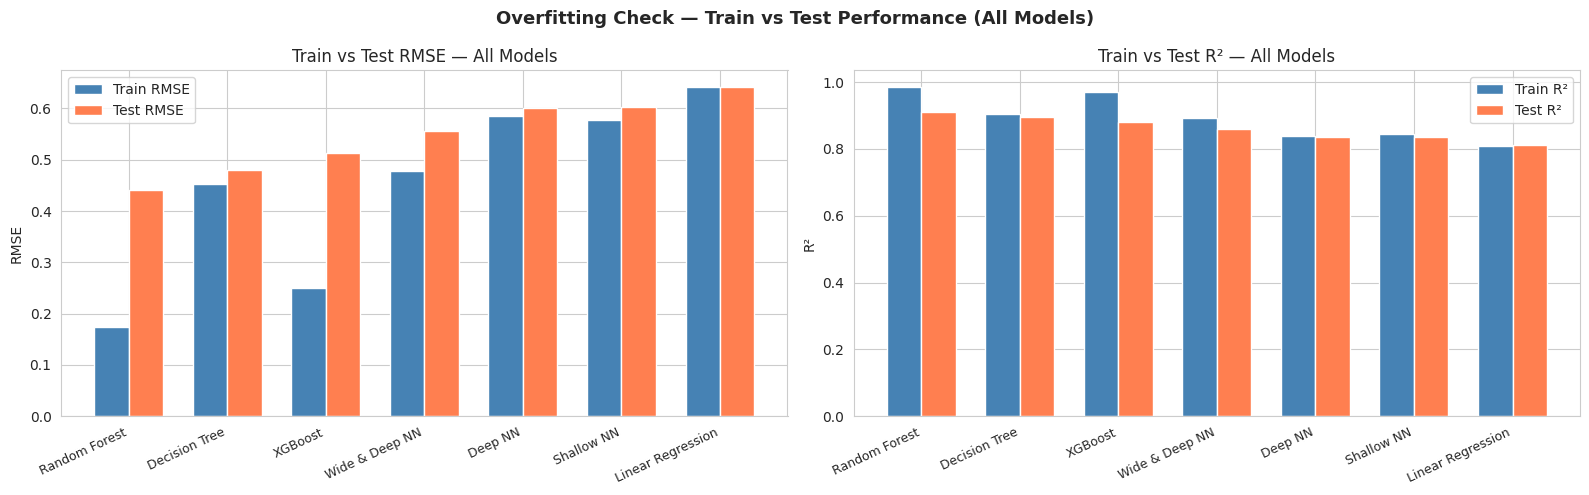

In [ ]:
# ── Train vs Test gap (overfitting check) — all 7 models ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
x = np.arange(len(model_names))
w = 0.35

axes[0].bar(x - w/2, train_rmse, w, label='Train RMSE', color='steelblue', edgecolor='white')
axes[0].bar(x + w/2, test_rmse,  w, label='Test RMSE',  color='coral',     edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=25, ha='right', fontsize=9)
axes[0].set_ylabel('RMSE')
axes[0].set_title('Train vs Test RMSE — All Models')
axes[0].legend()

axes[1].bar(x - w/2, train_r2, w, label='Train R²', color='steelblue', edgecolor='white')
axes[1].bar(x + w/2, test_r2,  w, label='Test R²',  color='coral',     edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names, rotation=25, ha='right', fontsize=9)
axes[1].set_ylabel('R²')
axes[1].set_title('Train vs Test R² — All Models')
axes[1].legend()

plt.suptitle('Overfitting Check — Train vs Test Performance (All Models)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## **NN Key Takeaways**
| **Overfitting** | Random Forest shows the largest train/test RMSE gap — tree ensembles memorise training data. NNs with dropout are better regularised. |